# CSCI 3352 Biological Networks, Spring 2022, Prof. Clauset

# Lecture 10 lab : protein interaction network, models

***

**Team names**: Dominic Galgano, Oliver

***

This is an in-class "laboratory," in which you will explore the behavior of the gene duplication model described in class.

***
* [Documentation for networkx](https://networkx.github.io/documentation/stable/)

[//]: <> (Documentation for igraph Python https://igraph.org/python/ )

In [1]:
import networkx as nx
import numpy as np
import matplotlib
import matplotlib.pylab as plt
%matplotlib inline
import random as rnd
rnd.seed()

In [2]:
def drawG(G):
    # draw the graph G
    print(f'graph with n={G.order()} nodes and m={G.size()} edges:')
    nx.draw_networkx(G,with_labels=True,node_size=600,width=2) # draw it pretty
    limits=plt.axis('off')                                     # turn off axes
    plt.show()
    return

In [3]:
def plotDegsCCDF(degrees):
    # tabulate and display the CCDF Pr(K>=k)
    kmax    = 0
    kis     = []
    for _,ki in degrees:
        kis.append(ki)
        if ki > kmax: kmax = ki

    counts, bins = np.histogram(kis, bins=[i for i in range(kmax+2)], density=True)
    cumcounts = np.cumsum(counts)
    cumcounts = np.insert(cumcounts,0,0)
    plt.loglog(bins[1:-1], 1-cumcounts[1:-1], 'rs', alpha=0.5)
    plt.xlabel('Degree, k')
    plt.ylabel('Pr(K>=k)')
    plt.show()
    return

***
## Part 1 : duplication-mutation with complementation (DMC) model

In this experiment, you'll develop intuition for how gene duplication models build different kinds of network structures. The "duplication-mutation with complementation" (DMC) model is one of the most general network models of gene duplication. It's somewhat different from the simpler model we saw in Lecture 10.

During each duplication event $\{u\}\to \{u,v\}$, the DMC model allows for 
* *subfunctionalization*, in which $u$ and $v$ divide up $u$'s previous interaction partners,
* *neofunctionalization*, in which $v$ acquires novel interaction partners, and
* *complementation*, in which $u$ and $v$ also become interaction partners.

In pseudocode, here's how the DMC model works:

* (setup) choose $q$ and $q_c$, and set the number of nodes $n$ at the end
* (setup) define a "seed graph" $G_0=(V_0,E_0)$ with some initial topology
* at each time step $t < n$ of the simulation
  * (dup) choose a node $u\in V_{t-1}$, uniformly at random
  * (dup) create a new node $v$
  * for each $(u,x)\in E_{t-1}$
    * (copy) add the edge $(v,x)$ to $E_t$
    * with probability $q$ (modify a copied edge)
      * (subfun) flip a fair coin, and delete either $(u,x)$ or $(v,x)$
    * otherwise
      * (neofun) choose $y$ uniformly at random from $V_{t-1}$
      * (neofun) replace $(v,x)$ with $(v,y)$
  * (comp) with probability $q_c$, add the "complement" edge $(u,v)$ to $E_t$

In the version of the model given below, I've added a few flags that allow you to turn on and off different parts of the model. In addition, the DMC model is specifically a simple graph model, and to maintain this property, we allow any rewiring events that would duplicate an existing edge to simply be ignored.

#### Part 1,a: Building intuition about `q`
* For `n=40` nodes, use the DMC simulation to explore the effect of `q` (the "edge modification rate"), which varies over $[0,1]$, on the kinds of graphs DMC grows. (Set `qc=1`, always complement, and `flag_neo=0`, no rewiring yet). Inspect the results closely. When $n$ is this small, the simulation will report what decisions it makes, and show you the intermediate graph $G_t$. When it halts, it tabulates and shows the degree distribution.
* Discuss with your teammates whether this model does or does not perform as expected, in light of the discussion in Lecture 10. If it does not perform as expected, develop hypotheses as to why. Record your insights in the markdown box below.

Hint: on paper, draw a line representing the range of `q`, and annotate different parts of the line (imagine dividing `q` up into increments of 0.1 or 0.25) with your summary of the qualitative network structure DMC builds with a `q` around that value.

Your `Part 1,a` discussion here

By increasing the value of q, the overall variance in edge wealth decreases. This is as expected because q regulates how many edges exist between a duplicate node and an existing node. The lower the q value the more edges are present, creating cliques among the protiens

#### Part 1,b: Building intuition about `qc` and `flag_neo`
* Repeat the experiment in `Part 1,a`, but now vary `qc` and `flag_neo`. Discuss with your teammates, and record below for which values of `q` these differences seem to have a substantial impact on the resulting network structure, and what those differences are.

Hint: on paper, draw two unit squares, each where the x-axis represents the range of `q` and the y-axis the range of `qc`, one square for `flag_neo=0` and one square for `flag_neo=1`. Then, annotate different parts of the square with your summary of the qualitative network structure DMC builds for that choice of (`q`,`qc`,`flag_neo`). (This is a kind of [phase diagram](https://en.wikipedia.org/wiki/Phase_diagram), if you're familiar with that term.)

Your `Part 1,b` discussion here

When we set the rewiring flag to true it seems to have little effect on higher on higher q values, likely because we are removing most of the edges we are modifying. At lower q values the edge wealth seems to have a greater variance when we set the rewiring flag to true, which is also as expected because rewiring means instead of even distributing all edges amongst new nodes, attempt to rewire them to the old node.


#### Part 1,c: Growing large networks via DMC
* Choose three values of `q` that represent qualitatively different types of graphs, and then run the DMC simulation for `n=1000` nodes (or larger, as necessary). (Keep `qc=1` and `flag_neo=0`).
* Discuss with your teammates whether this model does or does not perform as expected, in light of the discussion in Lecture 10. If it does not perform as expected, develop hypotheses as to why. Record your thoughts in the markdown box below.

Your `Part 1,c` discussion here

Yes, increasing the node count does not significantly change the way the model works.

#### Part 1,d: Quantifying the shape of growing DMC networks
* Now augment the DMC simulation so that it calculates, for each $G_t$ in the simulation:
  * the mean degree $\langle k \rangle$,
  * calculates the mean geodesic distance $\langle \ell \rangle$, and
  * calculates the clustering coefficient $C$, <br/>
  and plots the trends in nice figures.
* Choose some parameters `q`, `qc`, and `flag_neo` (your choice), and run the DMC simulation to produce those trends.
* Discuss with your teammates what these patterns tell you about how the graph's structure is evolving, and record your insights in the markdown box below.

Your `Part 1,d` discussion here

<k> = 
<l> =
C =


#### Part 1,e: (optional) Tinker, tinker
There are a number of places where additional modifications could be made to this model. For instance:
* In the subfunctionalization logic, currently $u$ and $v$ have an equal chance of getting to keep a partner $x$ to themselves. This could be modified to skew the probability toward $u$ or $v$.
* The node $u$ or the node $y$ could be chosen *non-uniformly* in some way, e.g., as a function of some node-level network measures about them.
* Etc. (What else can you come up with?)

In this optional activity, tinker with the structure of the DMC simulation and see what you can make happen.

****

In [24]:
def compute_MGD(G):
    # input : a networkx graph G
    # output: the mean geodesic path length (defined in Lecture 2)

    # YOUR CODE HERE
    output = nx.all_pairs_shortest_path_length(G)
    
    num_paths = 0 #Tracks total number of paths in graph with lengths greater than 0 and less than infinity
    total_distance = 0 #Tracks the total distance of all shortest paths with lengths greater than 0 and less than infinity 
    for x, y in output: #Cycles through all pairs of shortest path lengths
        ##print(x, y)
        #Sums together current shortest path number with total number of shortest paths
        #Subtracts 1 to avoid counting the path of length 0 from a node into itself
        num_paths = num_paths + (len(y.values()) - 1) 
        #Sums together current shortest path distance with total distance of shortest paths
        total_distance = total_distance + sum(y.values()) 
    
    if(num_paths > 0):
        mean = total_distance / num_paths
    else:
        print("No paths exists! Determining <l> to be 0.")
        mean = 0
    
    return mean

def displayInfo(G):
    n = G.number_of_nodes()
    m = G.number_of_edges()
    k = 2 * m / n
    print(f"<k> = {k}")
    
    l = compute_MGD(G)
    print(f"<l> = {l}")
    
    C = nx.transitivity(G)
    print(f"C = {C}")

    return k,l,C

In [25]:
# 1. DMC simulation setup
G  = nx.Graph([(1,2),(1,3),(1,4)]) # seed graph G0
n0 = G.order()
q  = 0.9
# edge modification rate (subfunctionalization)
qc = 1       # complementarity rate
n  = 1000    # number of nodes at the end
flag_neo = 1 # use neofunctionalization or not (rewiring)

# 2. RUN DMC
all_k = []
all_l = []
all_C = []
time = []
for t in range(n0, n, 1):
    if n<50: drawG(G)

    # 2.1 duplication event
    nodes = list(G.nodes())    # list of current nodes
    u     = rnd.choice(nodes)  # choose a uniformly random node u
    v     = G.order()+1        # duplicate u (call it v)
    G.add_node(v)              # add v to G
    print(f'[node #{t+1}] duplicated node {u} --> {v}')

    # 2.2 divergence, per edge
    edges = list(G.edges(u))   # list of u's edges E_u
    for e in edges:            # for each (u,x) in E_u
        x = e[1]               #  (u,x) --> get x
        G.add_edge(v,x)        #  add duplicate (v,x)
        if n<50: print(f'  added edge {v,x}')
        
        # 2.2.1 edge modification
        if rnd.uniform(0,1) < q:  # for each pair (u,x) and (v,x)
            # subfunctionalization: either u or v gets to keep x
            if rnd.uniform(0,1) < 1/2:
                G.remove_edge(v,x) # u keeps the partner, (u,x)
                if n<50: print(f'    kept edge {u,x}, removed edge {v,x}')
            else:
                G.remove_edge(u,x) # v gets the partner, (v,x)
                if n<50: print(f'    kept edge {v,x}, removed edge {u,x}')

        else:
        # 2.2.2 neofunctionalization
            if flag_neo == 1:
                y = rnd.choice(nodes) # choose y for rewiring
                G.remove_edge(v,x)    # delete (v,x)
                G.add_edge(v,y)       # add (v,y)
                if n<50: print(f'    rewired edge {v,x} to {v,y}')

    # 2.3 complementation
    if rnd.uniform(0,1) < qc: # add complement edge (u,v)
        G.add_edge(u,v)
        if n<50: print(f'  added complement edge {u,v}')
    
    k,l,C = displayInfo(G)
    all_k.append(k)
    all_l.append(l)
    all_C.append(C)
    time.append(t)

# 3.1 draw the final graph
if n<200: drawG(G)

# 3.2 tabulate and display the CCDF Pr(K>=k)
plotDegsCCDF(nx.degree(G))

plt.plot(time, all_k, color="red")
plt.plot(time, all_l, color="blue")
plt.plot(time, all_C, color="green")
plt.xlabel('time, t')
plt.ylabel('Pr(K>=k)')
plt.show()

[node #5] duplicated node 4 --> 5
<k> = 1.6
<l> = 1.8


ValueError: Precision not allowed in integer format specifier

***
## Part 2 : a directed duplication-divergence model

The simulation results shown in Lecture 8 are from a directed version of the duplication-divergence (DD) model, which lacks complementation, and has a different way of doing the edge copying. Here's pseudocode for this version of the model:

* (setup) choose $q$ and $q_c$, and set the number of nodes $n$ at the end
* (setup) define a "seed graph" $G_0=(V_0,E_0)$ with some initial topology
* at each time step $t < n$ of the simulation
  * (dup) choose a node $u\in V_{t-1}$, uniformly at random
  * (dup) create a new node $v$
  * for each directed edge $(u,x)\in E_{t-1}$
    * with probability $q$
      * (subfun) add directed edge $(v,x)$ to $E_t$
    * otherwise
      * (neofun) choose $y$ uniformly at random from $V_{t-1}$
      * (neofun) add directed edge $(v,y)$ to $E_t$

As before, any rewiring events that duplicate an existing directed edge will simply be ignored.

#### Part 2,a: What's the difference?
* Using the DD simulation code, simulate the growth process to create networks with a range of sizes (e.g. `n=10,50,1000` nodes), and inspect the output carefully.
* Vary `q` to explore the resulting shape of the network and the final degree distribution.
* Discuss with your teammates what differences you see in how this model behaves relative to the DMC model in `Part 1`, and in light of Lecture 8. Develop hypotheses as to why there are differences. Record your insights in the markdown box below.
* (optional) Augment the DD simulation to track and visualize trends in the model as it grows a network. Use the resulting trends to refine your hypotheses about why the small differences in the model result in any differences you observed in its behavoir.

Your `Part 2,a` discussion here

#### Part 2,b: (optional) Digging deeper
* Augment the DD simulation to track and visualize trends in the model as it grows a network. Use the resulting trends to refine your hypotheses about why the small differences in the model result in any differences you observed in its behavoir.

Your `Part 2,b` discussion here

****

[node #4] duplicated node 2 --> 4
[node #5] duplicated node 3 --> 5
[node #6] duplicated node 2 --> 6
[node #7] duplicated node 2 --> 7
[node #8] duplicated node 2 --> 8
[node #9] duplicated node 6 --> 9
[node #10] duplicated node 7 --> 10
[node #11] duplicated node 7 --> 11
[node #12] duplicated node 6 --> 12
[node #13] duplicated node 9 --> 13
[node #14] duplicated node 8 --> 14
[node #15] duplicated node 11 --> 15
[node #16] duplicated node 7 --> 16
[node #17] duplicated node 4 --> 17
[node #18] duplicated node 5 --> 18
[node #19] duplicated node 6 --> 19
[node #20] duplicated node 3 --> 20
[node #21] duplicated node 6 --> 21
[node #22] duplicated node 16 --> 22
[node #23] duplicated node 10 --> 23
[node #24] duplicated node 7 --> 24
[node #25] duplicated node 6 --> 25
[node #26] duplicated node 9 --> 26
[node #27] duplicated node 21 --> 27
[node #28] duplicated node 21 --> 28
[node #29] duplicated node 11 --> 29
[node #30] duplicated node 27 --> 30
[node #31] duplicated node 3 --> 

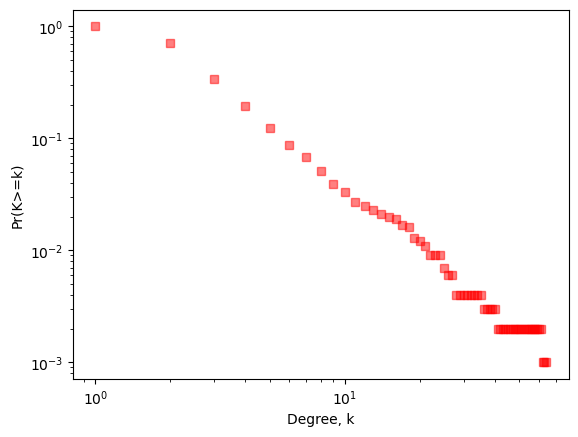

In [5]:
# 1. duplication-divergence simulation setup
G  = nx.DiGraph([(1,2),(2,3),(3,1),(2,1)]) # seed graph G0
n0 = G.order()
q  = 0.5    # edge copy fidelity
n  = 1000     # number of nodes at the end

# 2. RUN DD
for t in range(n0, n, 1):
    if n<50: drawG(G)

    # 2.1 duplication event
    nodes = list(G.nodes())    # list of current nodes
    u     = rnd.choice(nodes)  # choose a uniformly random node u
    v     = G.order()+1        # duplicate u (call it v)
    G.add_node(v)              # add v to Go
    print(f'[node #{t+1}] duplicated node {u} --> {v}')

    # 2.2 copy edges
    edges = list(G.edges(u))   # list of u's edges
    for e in edges:            # for each of those edges
        x = e[1]               # (u,x)
        if rnd.uniform(0,1) < q:
            # subfunctionalization: v keeps connection to x
            G.add_edge(v,x)
            if n<50: print(f'  copied edge {u,x} to {v,x}')
        else:
            # neofunctionalization: v connects to new node y
            y = rnd.choice(nodes) # rewire (v,x) to (v,y)
            G.add_edge(v,y)
            if n<50: print(f'  rewired edge {v,x} to {v,y}')

# 3.1 draw the final graph
if n<200: drawG(G)

# 3.2 tabulate and display the CCDF Pr(K>=k)
plotDegsCCDF(nx.degree(G))